# Load Necessary Packages and Dataset

In [1]:
# Install the chronos library and time series database
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git
!pip install -q tsdb

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import tsdb
from chronos import ChronosPipeline
from datetime import datetime
import torch

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the Data from TSDB library
# Air quality data of sites in Beijing

df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2025-08-11 18:49:25 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2025-08-11 18:49:25 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2025-08-11 18:49:25 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2025-08-11 18:49:25 [INFO]: Loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 61.0+ MB


In [5]:
# Change the target variable column name 'Demand' to 'y'

df = df.rename(columns={'TEMP': 'y'})
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [6]:
df['ds'] = pd.to_datetime(dict(year=df['year'],
                                     month=df['month'],
                                     day=df['day'],
                                     hour=df['hour']))

df = df.drop(['year', 'month', 'day', 'hour'], axis=1)
df = df.set_index('ds')
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
ds,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
2013-03-01 01:00:00,2,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2013-03-01 02:00:00,3,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
2013-03-01 03:00:00,4,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
2013-03-01 04:00:00,5,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


# EDA

We will focus on the `Wanilu` station.

In [7]:
df = df[df['station'] == 'Wanliu']
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
ds,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
2013-03-01 01:00:00,2,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2013-03-01 02:00:00,3,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
2013-03-01 03:00:00,4,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
2013-03-01 04:00:00,5,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


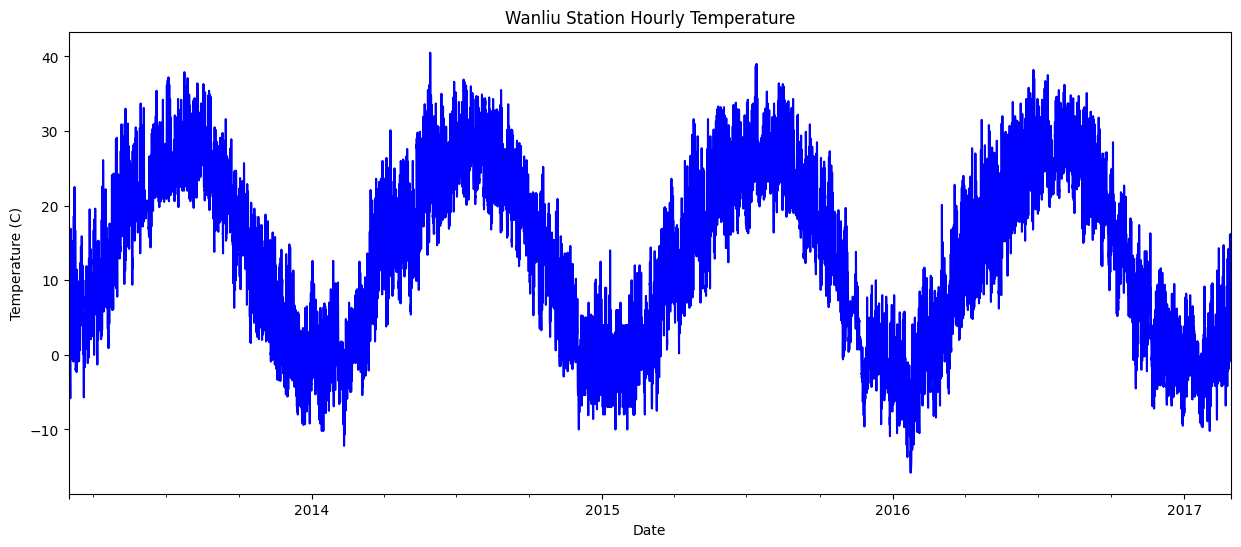

In [8]:
plt.figure(figsize=(15, 6))
df['y'].plot(title = 'Wanliu Station Hourly Temperature', color='blue')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.show()

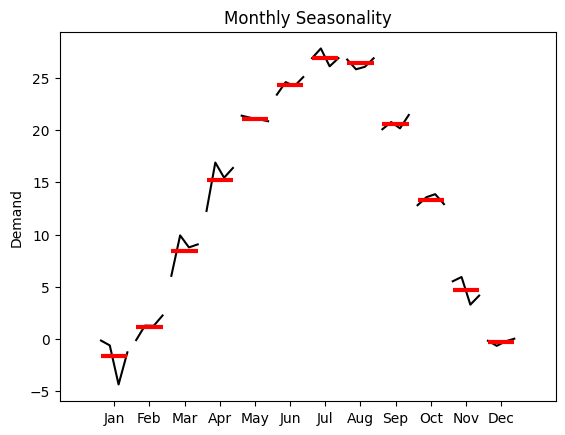

In [9]:
# Monthly Seasonality
month_plot(df['y'].resample('M').mean())
plt.title('Monthly Seasonality')
plt.ylabel('Demand')
plt.show()

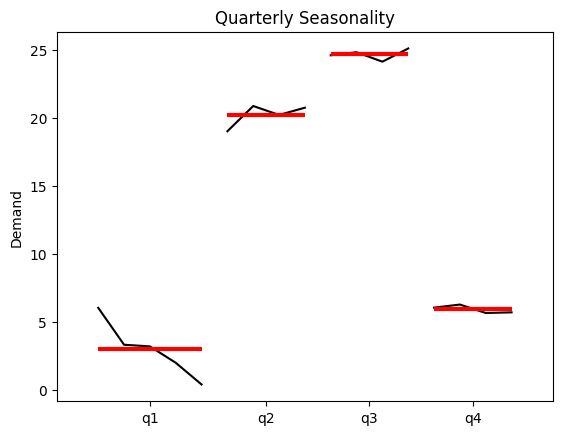

In [10]:
# Quarterly Seasonality

quarter_plot(df['y'].resample('Q').mean())
plt.title('Quarterly Seasonality')
plt.ylabel('Demand')
plt.show()

In [11]:
# Show rows where y is missing
df[df['y'].isna()]

,No,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
ds,,,,,,,,,,,,,,
2015-01-27 20:00:00,16749,22.0,46.0,20.0,76.0,1100.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2015-02-18 07:00:00,17264,19.0,19.0,20.0,58.0,800.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-14 15:00:00,31048,68.0,68.0,6.0,26.0,800.0,179.0,NaN,NaN,NaN,NaN,SW,3.1,Wanliu
2016-09-25 19:00:00,31316,172.0,181.0,2.0,63.0,1700.0,63.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-25 20:00:00,31317,184.0,184.0,2.0,75.0,1900.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-25 21:00:00,31318,150.0,150.0,2.0,41.0,1400.0,99.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-25 22:00:00,31319,107.0,107.0,2.0,28.0,1100.0,115.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-25 23:00:00,31320,105.0,111.0,2.0,29.0,1100.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,Wanliu
2016-09-26 00:00:00,31321,100.0,100.0,2.0,34.0,1100.0,75.0,NaN,NaN,NaN,NaN,NE,2.4,Wanliu


In [12]:
# Forward fill missing values
df['y_filled'] = df['y'].fillna(method='ffill').fillna(method='bfill')

In [13]:
# Subset df to just the 'y_filled' column
df = df[['y_filled']]
df.head()


,y_filled
ds,
2013-03-01 00:00:00,-0.7
2013-03-01 01:00:00,-1.1
2013-03-01 02:00:00,-1.1
2013-03-01 03:00:00,-1.4
2013-03-01 04:00:00,-2.0


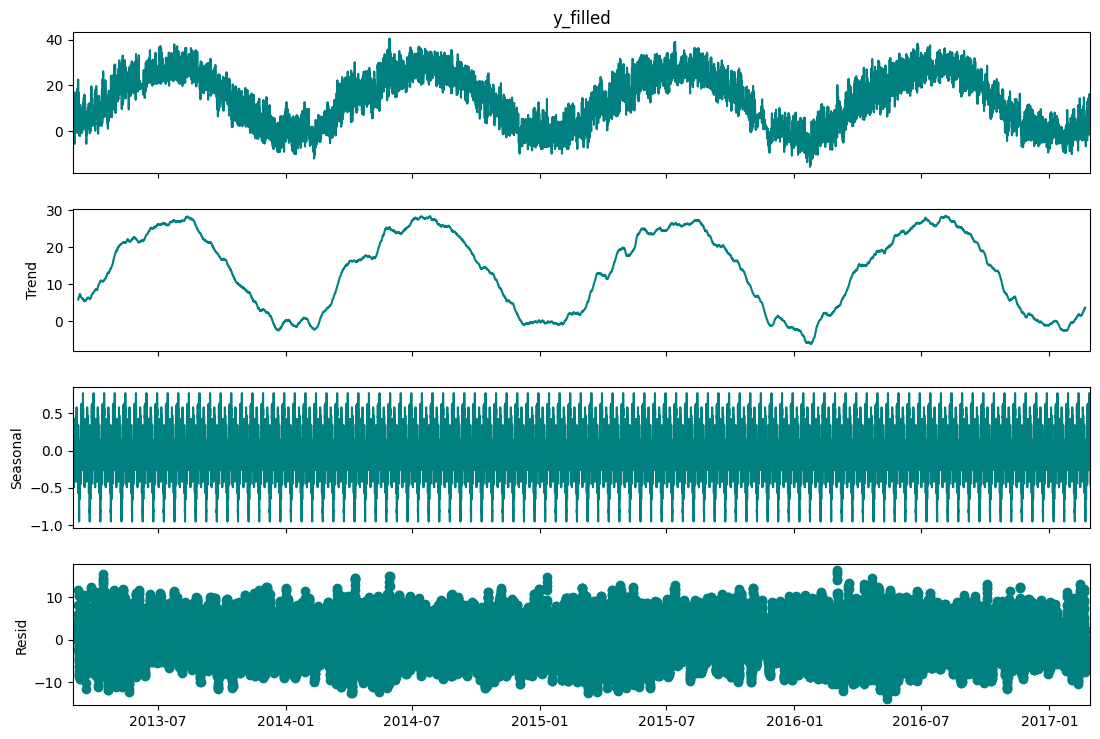

In [14]:
# Seasonal decomposition of 'Temperature'  (12 month period, model='additive')

result = seasonal_decompose(df['y_filled'], model='additive', period=365)
fig = result.plot()

# Change line color to blue for all axes
for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color('teal')

# Adjust figure size (if needed)
fig.set_size_inches(12, 8)
plt.show()


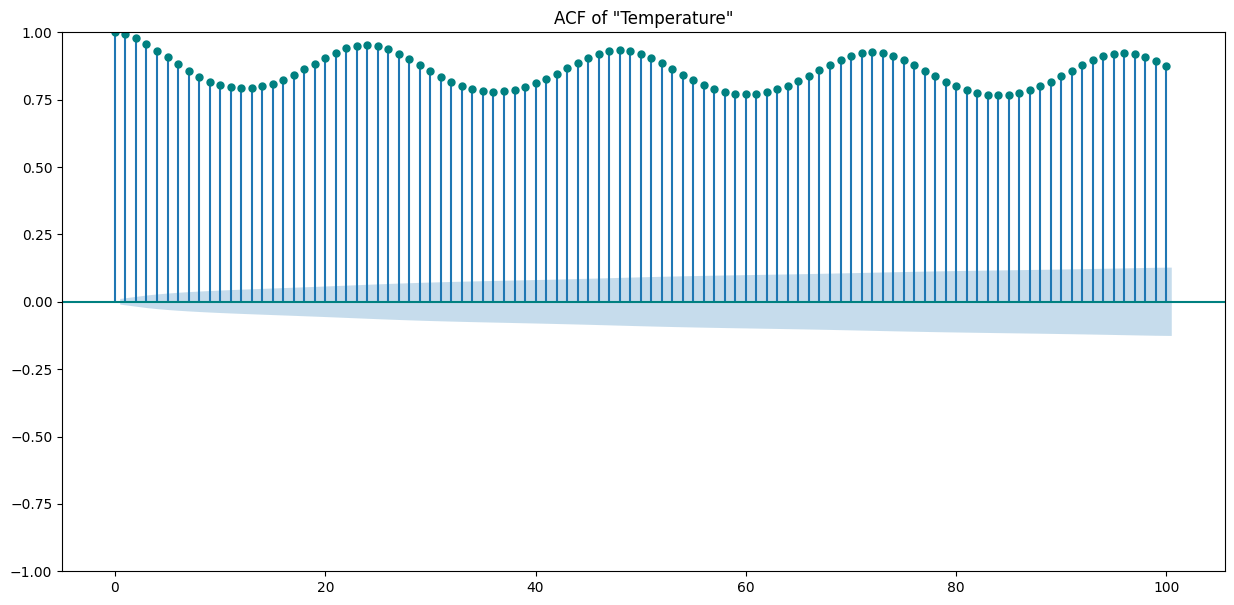

In [15]:
# Plot the ACF for the 'Demand' data
fig, ax = plt.subplots(figsize=(15,7))
plot_acf(df['y_filled'], lags=100, ax=ax, color='teal')
plt.title('ACF of "Temperature"')
plt.show()

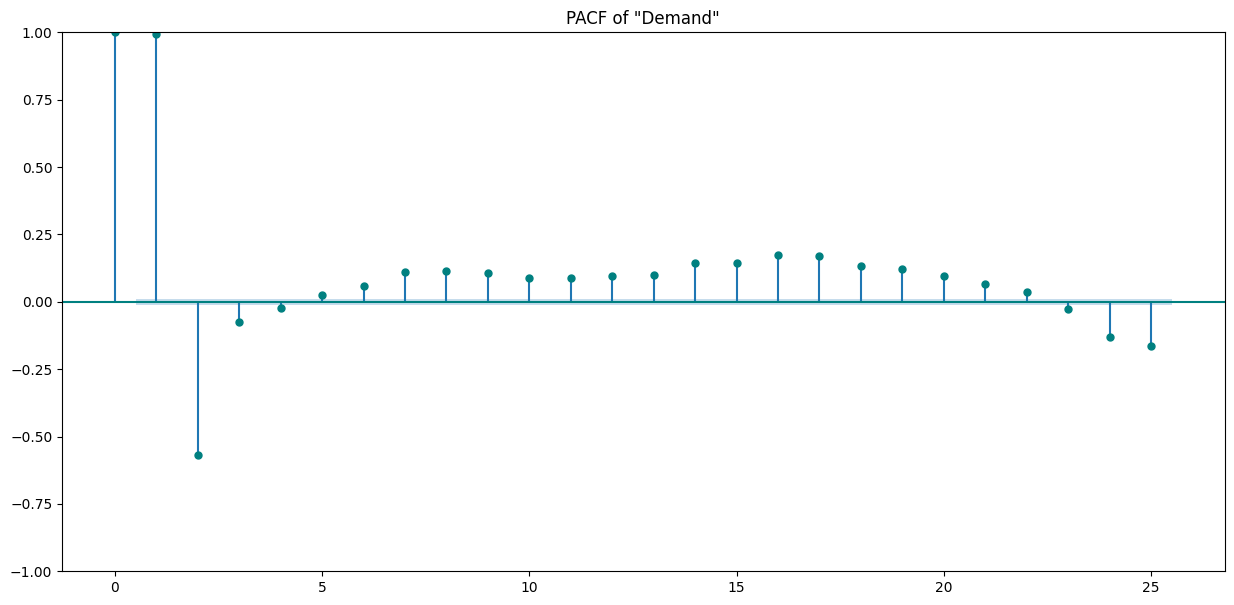

In [16]:
# PACF of 'Demand'
fig, ax = plt.subplots(figsize=(15,7))
plot_pacf(df['y_filled'], lags=25, ax=ax, color='teal')
plt.title('PACF of "Demand"')
plt.show()

# Prepare Pipeline for Amazon Chronos

In [17]:
# Start a pipeline from the pre-trained model

pipeline = ChronosPipeline.from_pretrained('amazon/chronos-t5-base')

In [18]:
# Get help about the parameters
print(ChronosPipeline.predict.__doc__)


        Get forecasts for the given time series.

        Refer to the base method (``BaseChronosPipeline.predict``)
        for details on shared parameters.

        Additional parameters
        ---------------------
        num_samples
            Number of sample paths to predict. Defaults to what
            specified in ``self.model.config``.
        temperature
            Temperature to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_k
            Top-k parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_p
            Top-p parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        limit_prediction_length
            Force prediction length smaller or equal than the
            built-in prediction length from the model. False by
            default. When true, fail loudly if longer p

In [19]:
# Build the forecast

forecast = pipeline.predict(
          context=torch.tensor(df['y_filled'].values), # Convert DataFrame values to a tensor
          temperature=1.0,
          top_k=50,
          top_p=1.0,
          prediction_length=72,
          num_samples=20,
          limit_prediction_length=False
          )

In [20]:
forecast

tensor([[[ 6.0943,  5.7912,  5.7912,  ...,  8.9995,  7.3170,  6.1040],
         [ 6.5993,  7.1717,  7.3737,  ..., 10.0951,  8.0995,  5.7910],
         [ 4.8148,  3.6027,  3.4007,  ...,  7.5909,  5.9866,  5.9866],
         ...,
         [ 6.5993,  5.9932,  6.3973,  ...,  7.1213,  5.5953,  5.2041],
         [ 6.8013,  5.1852,  3.8047,  ..., 10.0951,  9.2734,  7.7865],
         [ 5.2862,  5.6902,  5.4882,  ..., 10.9950,  8.6865,  7.5126]]])

In [21]:
forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim=0)
forecast_mean

tensor([ 6.0943,  5.7912,  5.7912,  7.6094,  8.5185,  8.2155,  7.0033,  7.5084,
         8.2155, 11.0101, 12.8282, 13.9730, 14.5791, 15.1515, 15.3535, 15.3535,
        14.3097, 12.9966, 12.3905, 10.6734, 10.2357,  7.8114,  8.6195,  7.1044,
         5.9932,  6.2963,  5.8249,  5.4209,  4.1077,  3.1986,  1.0101,  1.4141,
         3.4007,  8.3838, 11.3131, 12.6262, 13.4006, 14.3097, 15.1178, 15.7912,
        15.0168, 13.9057, 12.0538, 10.8080,  9.0909,  7.8114,  5.6902,  3.7037,
         3.2997,  2.8956,  2.1885,  0.7071,  0.6061,  0.9091, -0.1010,  1.0101,
         3.8047,  7.0033,  8.9899, 10.4377, 11.4141, 12.3569, 13.2660, 14.2424,
        13.7731, 13.1080, 10.9950, 10.2125,  9.8994,  8.9995,  7.3170,  6.1040])

# Cross Validation

In [22]:
# Define some basic parameters

forecast_horizon = 72
stride = 48

# Determine the starting date for cross-validation, using a window of the forecast horizon multiplied by 10
start_date = df.index[-forecast_horizon * 10]
print(start_date)

# Determine the end date of the dataset
end_date = df.index[-1]
print(end_date)


2017-01-30 00:00:00
2017-02-28 23:00:00


In [26]:
# Start an empty list and define dates

results = []
current_date = start_date

while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:
  # Split the data into train and test
  train = df[df.index < current_date]
  test = df[current_date : current_date + pd.Timedelta(hours = forecast_horizon - 1)]

  # Generate the forecasts
  forecast = pipeline.predict(context = torch.tensor(train['y_filled'].values),
                              temperature = 1.0,
                              top_k = 50,
                              top_p = 1.0,
                              prediction_length = 72,
                              num_samples = 20,
                              limit_prediction_length = False)
  forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

  # Compute and print the RMSE
  error = np.sqrt(mean_squared_error(torch.tensor(test['y_filled'].values),
                                      forecast_mean))
  print(f"The RMSE is {error}")
  results.append((current_date, error))
  current_date += pd.Timedelta(hours = stride)

The RMSE is 2.2008878899675963


The RMSE is 3.52038736135428


The RMSE is 5.713141650718923


The RMSE is 2.5012657991216822


The RMSE is 1.875302496194401


...

The RMSE is 3.2771770332556365


The RMSE is 4.536640564738151


The RMSE is 3.099814794874704


The RMSE is 3.0458219999371035


The RMSE is 4.514461645726196
The RMSE is 5.963807628264806


In [27]:
def time_series_cv(pipeline, df, forecast_horizon, stride, start_date, end_date):
  # Initialize an empty list to store results
  results = []
  # Set the current date to the start date
  current_date = start_date

  while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:
    # Define the training and test sets based on the current date
    train = df[df.index < current_date]
    test = df[current_date : current_date + pd.Timedelta(hours = forecast_horizon - 1)]

    # Generate forecasts using the pipeline
    forecast = pipeline.predict(context = torch.tensor(train['y_filled'].values),
                              temperature = 1.0,
                              top_k = 50,
                              top_p = 1.0,
                              prediction_length = 72,
                              num_samples = 20,
                              limit_prediction_length = False)
    forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

    # Compute and print the RMSE for the forecasts
    error = np.sqrt(mean_squared_error(torch.tensor(test['y_filled'].values),
                                      forecast_mean))
    print(f"The RMSE is {error}")
    results.append((current_date, error))

    # Move to the next time window
    current_date += pd.Timedelta(hours = stride)

  return results

In [28]:
# Test the time series cross-validation function with the defined parameters
results = time_series_cv(pipeline,
                         df,
                         forecast_horizon,
                         stride,
                         start_date,
                         end_date)

The RMSE is 2.2321680172368823


The RMSE is 3.6587930629828964


The RMSE is 5.46412913921641


The RMSE is 2.546799526655084


The RMSE is 2.0330898650100306


...

The RMSE is 5.1954450254366895


The RMSE is 4.346439541611843


The RMSE is 3.490782257432199


The RMSE is 3.362058774406262


The RMSE is 5.09305434501808
The RMSE is 4.794596589660089


In [29]:
# Convert the results list to a DataFrame for easier handling and visualization
results_df = pd.DataFrame(results, columns=["Date", "RMSE"])

# Print the average RMSE across all cross-validation splits
print(f"The average RMSE is {results_df['RMSE'].mean()}")

# Display the DataFrame containing the RMSE results for each date
results_df

The average RMSE is 3.994243363362827


,Date,RMSE
0,2017-01-30,2.232168
1,2017-02-01,3.658793
2,2017-02-03,5.464129
3,2017-02-05,2.546800
4,2017-02-07,2.033090
5,2017-02-09,3.398889
6,2017-02-11,5.860997
7,2017-02-13,4.442166
8,2017-02-15,5.195445
9,2017-02-17,4.346440


# Cross Validation Predictions Compared with Actuals

In [31]:
def time_series_cv(pipeline, df, forecast_horizon, stride, start_date, end_date):

  # Initialize lists to store results, predictions, and actuals
  results = []
  all_predictions = []
  all_actuals = []

  # Set the initial date for the cross-validation loop
  current_date = start_date

  while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:
    # Split the data into training and test sets
    train = df[df.index < current_date]
    test = df[current_date : current_date + pd.Timedelta(hours = forecast_horizon - 1)]

    # Generate forecasts from the model pipeline
    forecast = pipeline.predict(context = torch.tensor(train['y_filled'].values),
                              temperature = 1.0,
                              top_k = 50,
                              top_p = 1.0,
                              prediction_length = 72,
                              num_samples = 20,
                              limit_prediction_length = False)
    forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

    # Store the forecasts and actual values
    all_predictions.append(forecast_mean.numpy())
    all_actuals.append(torch.tensor(test['y_filled'].values).numpy())

    # Calculate the RMSE for the current forecast
    error = np.sqrt(mean_squared_error(torch.tensor(test['y_filled'].values),
                                      forecast_mean))
    print(f"The RMSE is {error}")
    results.append((current_date, error))

    # Move to the next date for the next iteration
    current_date += pd.Timedelta(hours = stride)

  return results, all_predictions, all_actuals

In [32]:
# Apply the cross-validation function to evaluate the model
results, all_predictions, all_actuals = time_series_cv(pipeline,
                                                        df,
                                                        forecast_horizon,
                                                        stride,
                                                        start_date,
                                                        end_date)

The RMSE is 5.926594252631786


The RMSE is 3.7965804476157663


The RMSE is 5.047257485384923


The RMSE is 3.0150764597721005


The RMSE is 2.5537287310950565


...

The RMSE is 4.817547529022832


The RMSE is 3.153687772250782


The RMSE is 2.8616953878074565


The RMSE is 3.7657561224225784


The RMSE is 4.772478528849534
The RMSE is 6.112045355750367


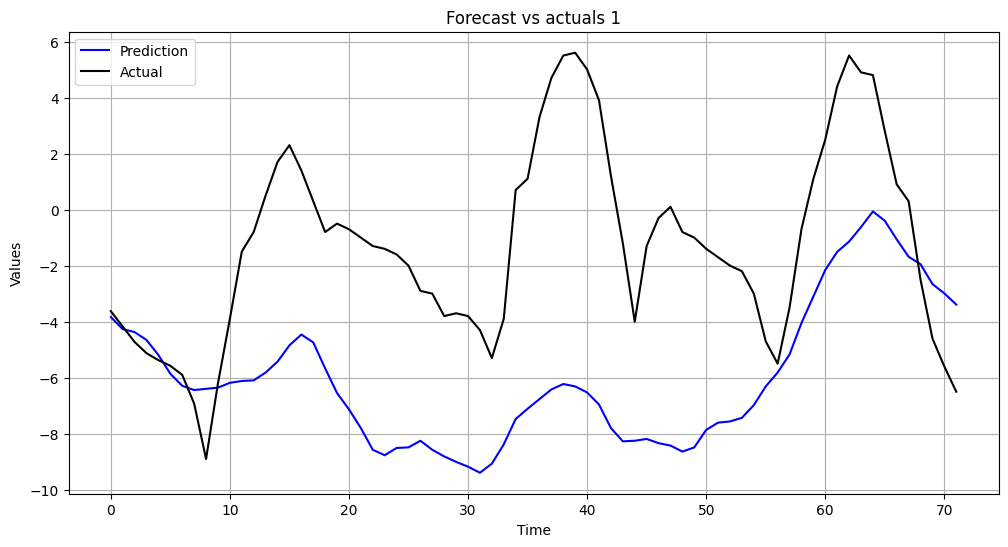

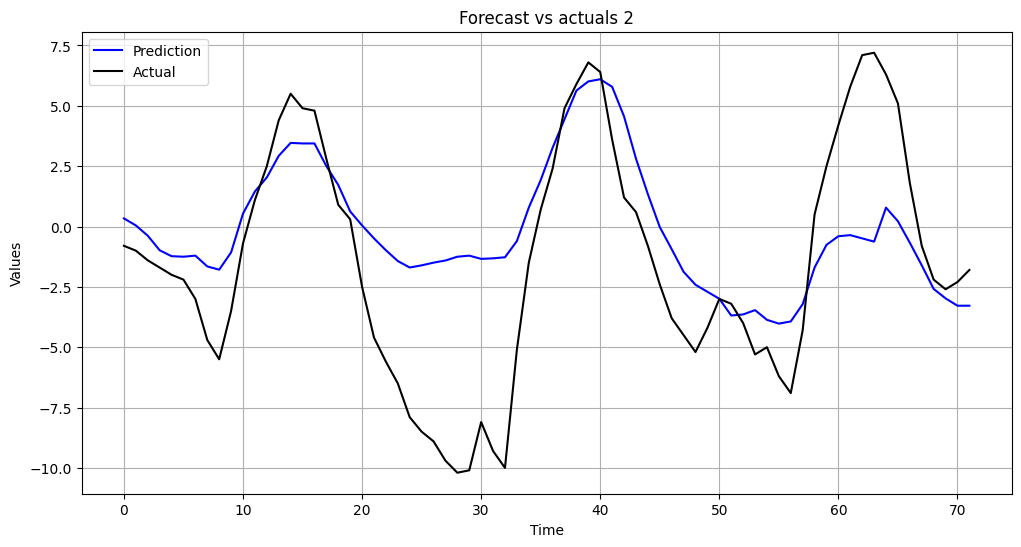

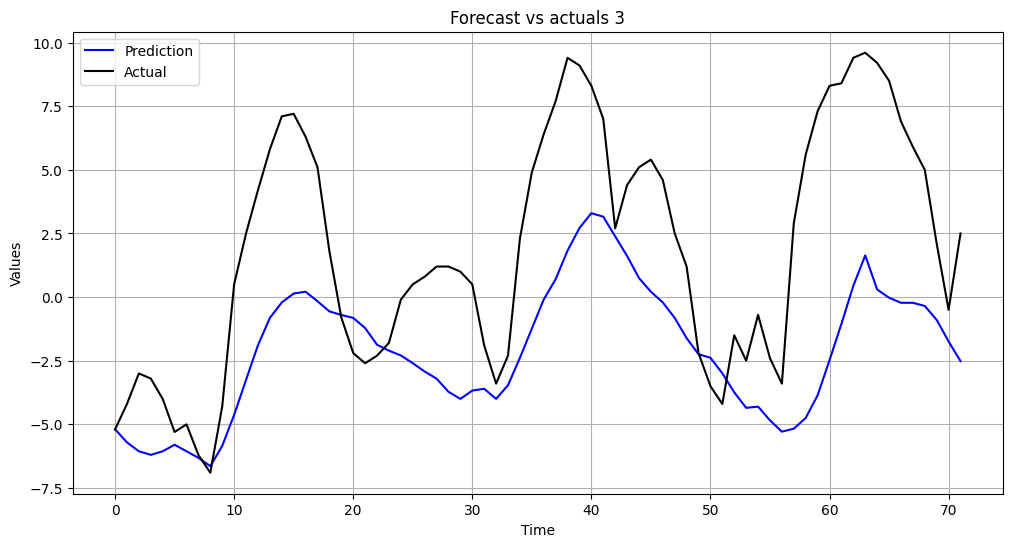

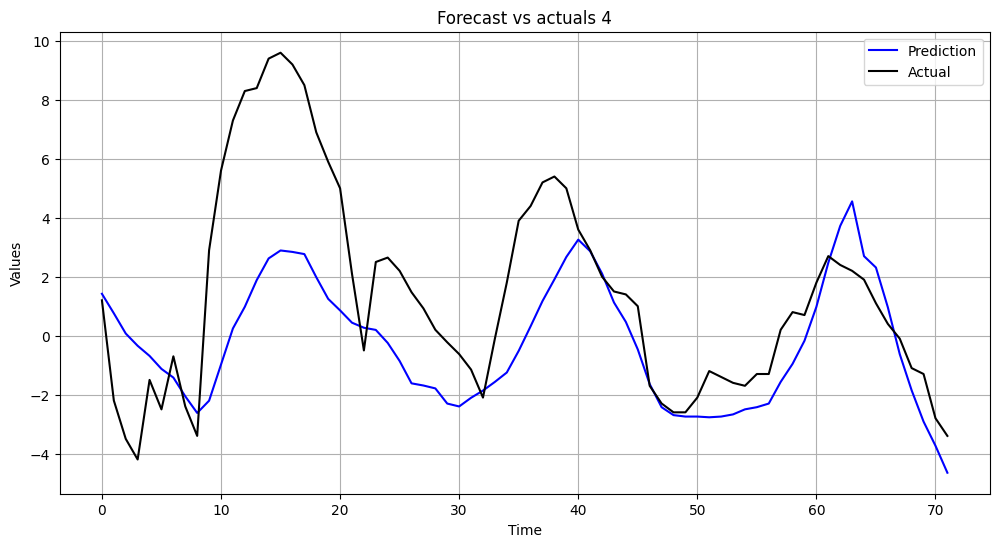

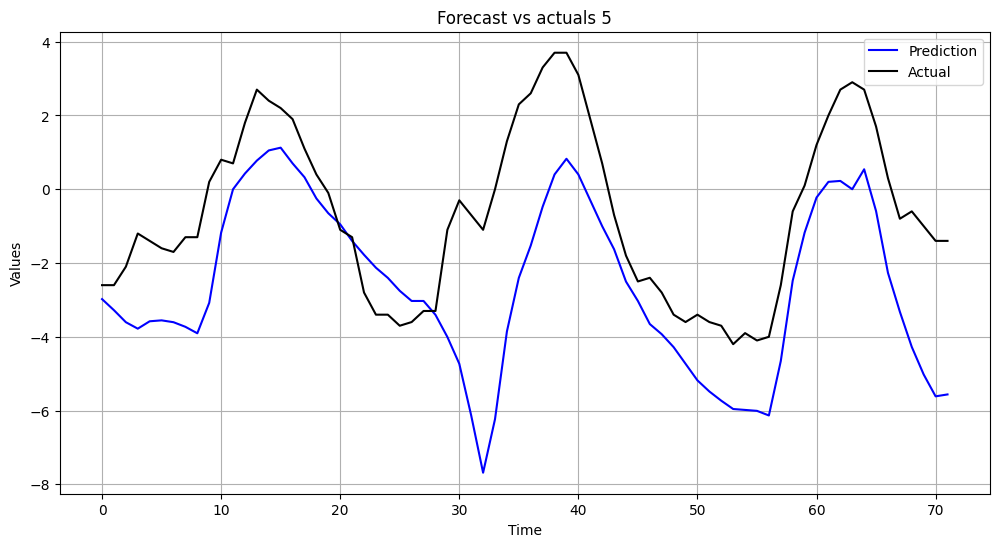

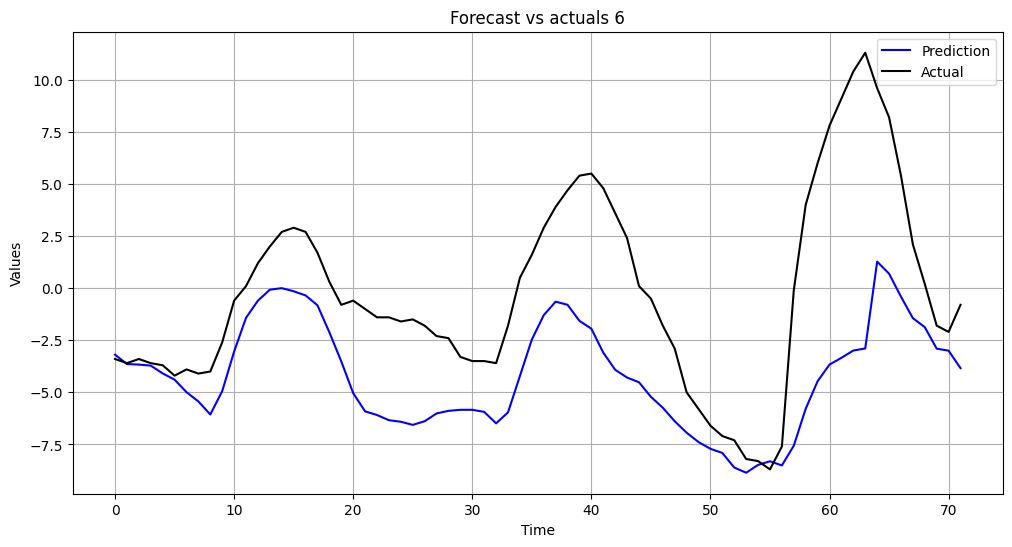

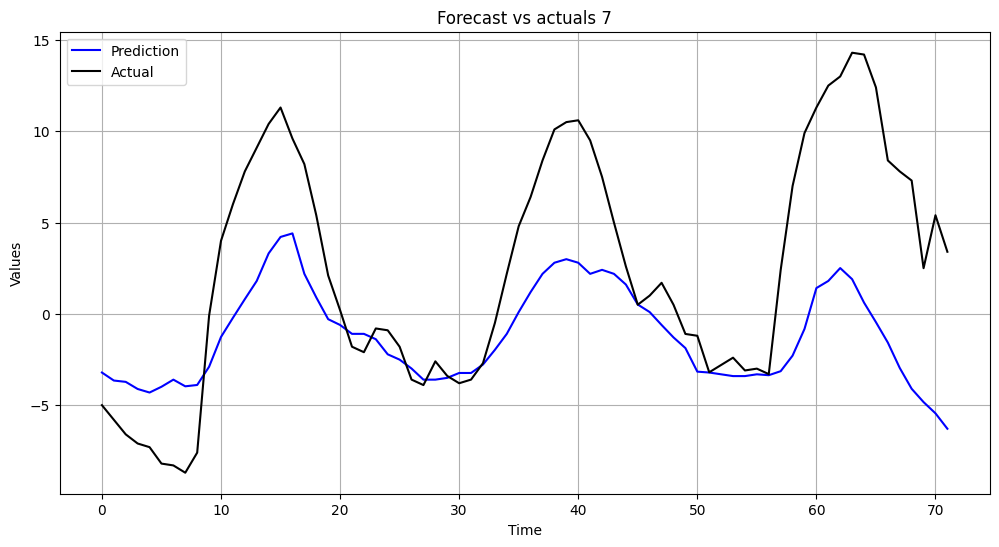

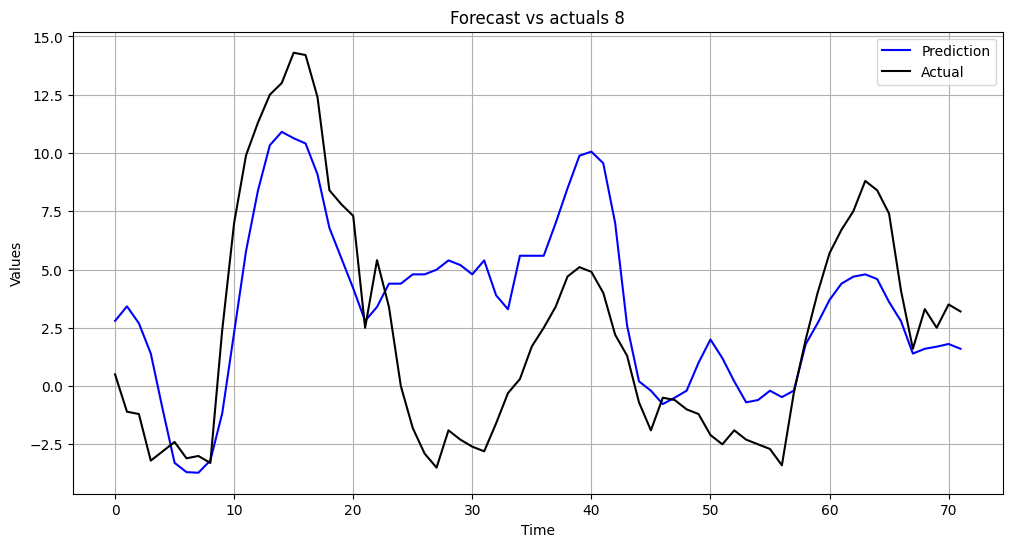

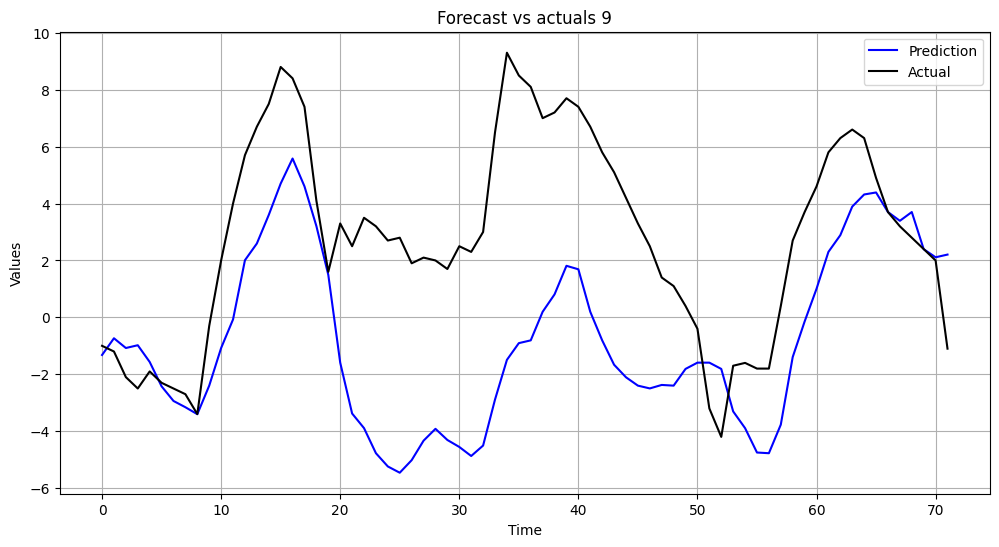

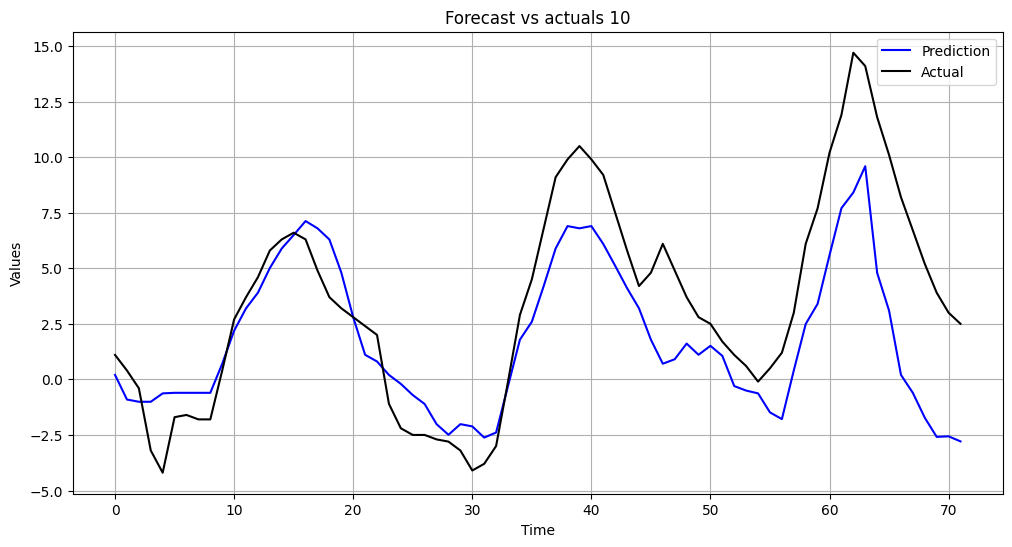

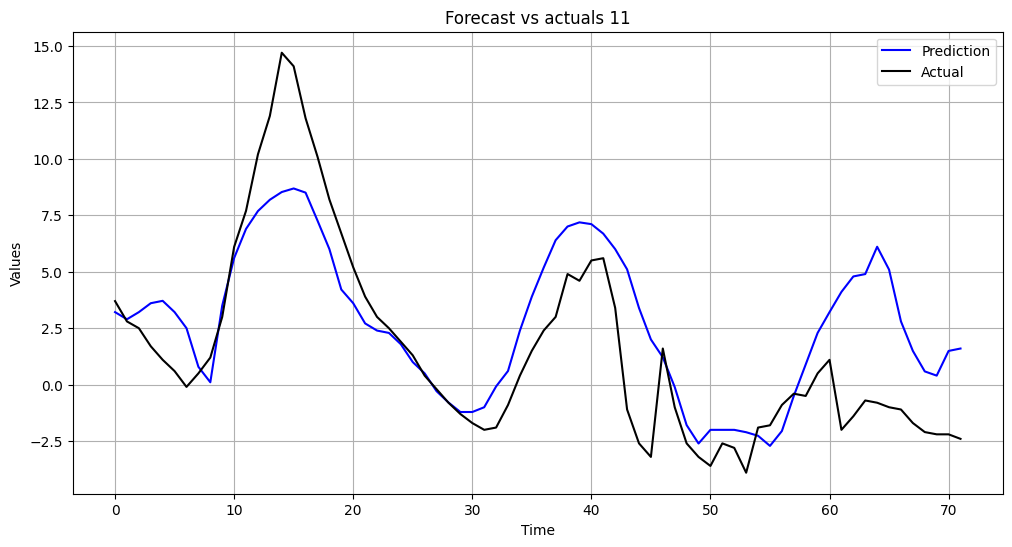

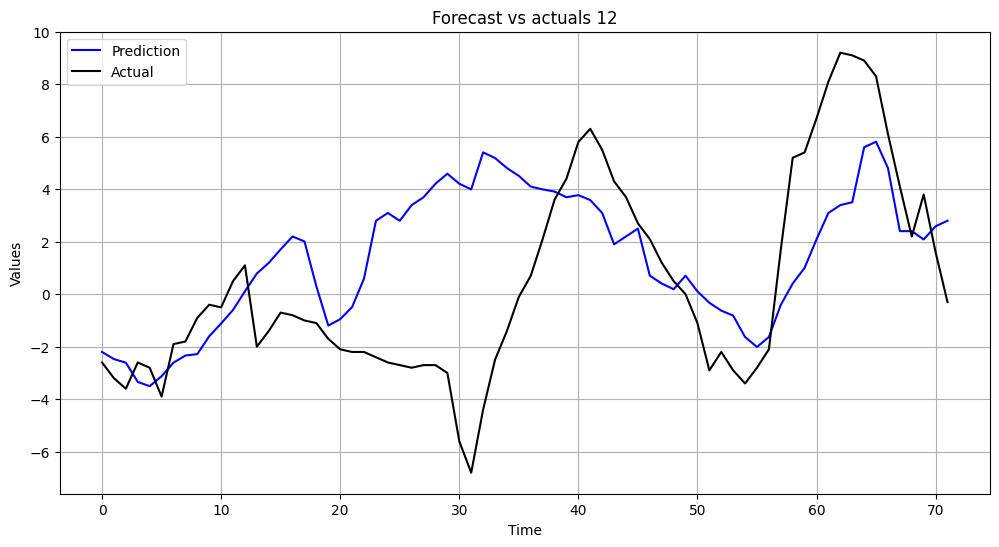

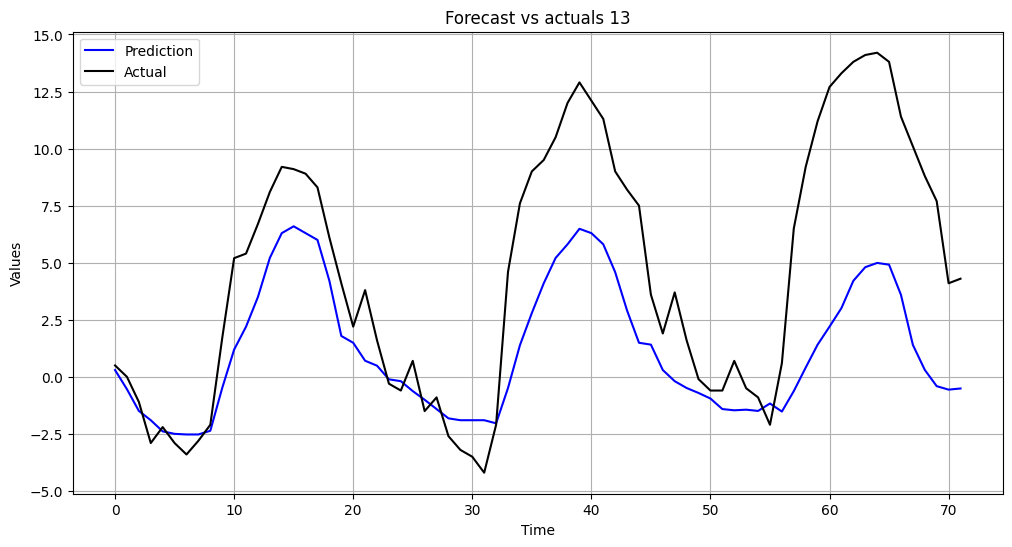

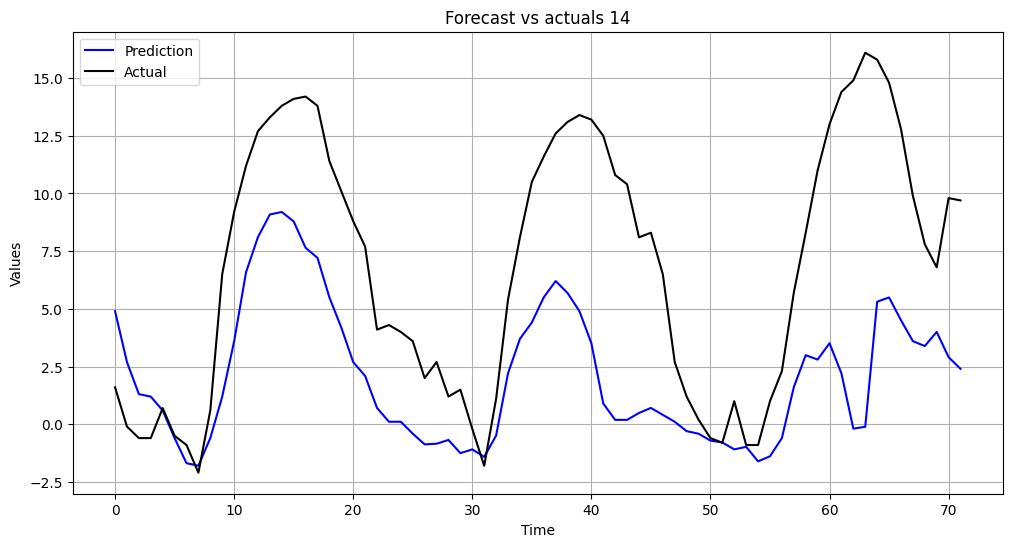

In [33]:
# Plot the predictions and actual values
for i in range(len(all_predictions)):
  # set figure size
  plt.figure(figsize = (12, 6))

  # predictions
  plt.plot(all_predictions[i], label = "Prediction", color = "blue")
  # actual
  plt.plot(all_actuals[i], label = "Actual", color = "black")

  # set title, legend, and axis
  plt.title(f"Forecast vs actuals {i + 1}")
  plt.ylabel("Values")
  plt.xlabel("Time")
  plt.legend()
  plt.grid(True)
  plt.show()

# Hyperparameter Tuning

In [35]:
# Set up the parameter grid for hyperparameter tuning

param_grid = {
    "temperature": [0.1, 0.5, 1.0, 1.5],  # Controls randomness in the predictions
    "top_k": [10, 30, 50, 100],          # Number of top predictions to consider
    "top_p": [0.1, 0.5, 0.75, 1.0],      # Cumulative probability for sampling predictions
    "num_samples": [5, 10, 20, 50]        # Number of samples to draw for each prediction
}

In [36]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

[{'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 0.75},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 10, 'top_p': 1.0},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 30, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 30, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 30, 'top_p': 0.75},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 30, 'top_p': 1.0},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 50, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 50, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 50, 'top_p': 0.75},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 50, 'top_p': 1.0},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'to

In [37]:
import random

# Sample a subset of N combinations from the generated list
random.seed(42)  # Set seed for reproducibility
sampled_combinations = random.sample(all_params, 10)  # Sample 10 combinations

sampled_combinations

[{'num_samples': 5, 'temperature': 1.5, 'top_k': 50, 'top_p': 0.5},
 {'num_samples': 5, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 20, 'temperature': 0.1, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 10, 'temperature': 1.5, 'top_k': 100, 'top_p': 0.5},
 {'num_samples': 10, 'temperature': 1.5, 'top_k': 10, 'top_p': 0.75},
 {'num_samples': 10, 'temperature': 0.1, 'top_k': 30, 'top_p': 1.0},
 {'num_samples': 5, 'temperature': 1.5, 'top_k': 30, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 1.0, 'top_k': 100, 'top_p': 0.1},
 {'num_samples': 50, 'temperature': 0.5, 'top_k': 50, 'top_p': 0.1},
 {'num_samples': 5, 'temperature': 0.5, 'top_k': 10, 'top_p': 0.1}]

In [40]:
def time_series_cv_tuning(pipeline, df, forecast_horizon, stride, start_date, end_date, params):
  # Initialize lists to store results, predictions, and actuals
  results = []
  all_predictions = []
  all_actuals = []

  # Set the initial date for the cross-validation loop
  current_date = start_date

  while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:
    # Split the data into training and test sets
    train = df[df.index < current_date]
    test = df[current_date : current_date + pd.Timedelta(hours = forecast_horizon - 1)]

    # Generate forecasts from the model pipeline
    forecast = pipeline.predict(context = torch.tensor(train['y_filled'].values),
                              temperature = params['temperature'],
                              top_k = params['top_k'],
                              top_p = params['top_p'],
                              prediction_length = forecast_horizon,
                              num_samples = params['num_samples'],
                              limit_prediction_length = False)
    forecast_mean = torch.mean(torch.stack([f[0] for f in forecast]), dim = 0)

    # Store the forecasts and actual values
    all_predictions.append(forecast_mean.numpy())
    all_actuals.append(torch.tensor(test['y_filled'].values).numpy())

    # Calculate the RMSE for the current forecast
    error = np.sqrt(mean_squared_error(torch.tensor(test['y_filled'].values),
                                      forecast_mean))
    print(f"The RMSE is {error}")
    results.append((current_date, error))

    # Move to the next date for the next iteration
    current_date += pd.Timedelta(hours = stride)

  return results, all_predictions, all_actuals

In [41]:
# Initialize a list to store RMSE results
rmse_results = []

for params in sampled_combinations:
  # Perform cross-validation with the current set of parameters
  results, _, _ = time_series_cv_tuning(pipeline,
                                        df,
                                        forecast_horizon,
                                        stride,
                                        start_date,
                                        end_date,
                                        params)

  # Calculate and store the mean RMSE for the current parameter set
  mean_rmse = np.mean([error for _, error in results])
  rmse_results.append({**params, 'rmse': mean_rmse})

  # Print the RMSE for the current parameter set
  print(f"RMSE for {params}: {mean_rmse}")


The RMSE is 2.865996231441301


The RMSE is 4.044703411060594


The RMSE is 7.323046599443243


The RMSE is 2.900607674242177


The RMSE is 3.1493482857186264


...

The RMSE is 3.811697635462697


The RMSE is 5.583367549862399


The RMSE is 2.925885997586372


The RMSE is 3.1731671120512335


The RMSE is 5.566838378083379
The RMSE is 6.06831804265237
RMSE for {'num_samples': 5, 'temperature': 0.5, 'top_k': 10, 'top_p': 0.1}: 4.253353515089078


In [42]:
# Put the result in a DataFrame
rmse_df = pd.DataFrame(rmse_results)
rmse_df

,num_samples,temperature,top_k,top_p,rmse
0,5,1.5,50,0.50,4.366362
1,5,0.1,100,0.10,4.317879
2,20,0.1,100,0.10,4.308854
3,10,1.5,100,0.50,3.943658
4,10,1.5,10,0.75,3.903283
5,10,0.1,30,1.00,4.012351
6,5,1.5,30,0.10,4.195547
7,5,1.0,100,0.10,4.124594
8,50,0.5,50,0.10,4.336264
9,5,0.5,10,0.10,4.253354


In [44]:
# Identify the parameter set(s) with the lowest RMSE and export it to a CSV file
best_params = rmse_df.sort_values('rmse').iloc[0]
best_params.to_csv('best_params.csv')
best_params

,4
num_samples,10.000000
temperature,1.500000
top_k,10.000000
top_p,0.750000
rmse,3.903283


# Predict the Future

In [45]:
# Transform the best parameters into a dictionary
best_params_dict = best_params.squeeze().to_dict()
best_params_dict

{'num_samples': 10.0,
 'temperature': 1.5,
 'top_k': 10.0,
 'top_p': 0.75,
 'rmse': 3.903282927850351}

In [46]:
# Build the tuned amazon chronos model

best_forecast = pipeline.predict(
        context = torch.tensor(df['y_filled'].values),  # Provide the entire dataset as context for prediction
        temperature = best_params_dict['temperature'],  # Set the temperature parameter for sampling
        top_k = int(best_params_dict['top_k']),  # Use the top_k parameter to control diversity of predictions
        top_p = best_params_dict['top_p'],  # Use the top_p parameter to control cumulative probability for sampling
        prediction_length = forecast_horizon,  # Specify the number of steps to forecast
        num_samples = int(best_params_dict['num_samples']),  # Define the number of samples for predictions
        limit_prediction_length = False)  # Allow predictions to exceed the default limit if set to False


In [47]:
# Compute the mean of the forecast across all samples
best_forecast_mean = torch.mean(torch.stack([f[0] for f in best_forecast]), dim = 0)

# Create an index for the forecast that starts immediately after the last index in the df
forecast_index = pd.date_range(start = df.index[-1] + pd.Timedelta(hours = 1),
                               periods = forecast_horizon,
                               freq = "H")

# Create a Pandas Series with the forecast values and index
forecast_series = pd.Series(
    best_forecast_mean.numpy(),  # Convert the tensor to a NumPy array
    index=forecast_index)  # Use the generated forecast index

forecast_series = forecast_series.rename("Amazon Chronos")  # Rename the series for clarity

forecast_series[:2]  # Display the first two values of the forecast

,Amazon Chronos
2017-03-01 00:00:00,6.498296
2017-03-01 01:00:00,5.589208


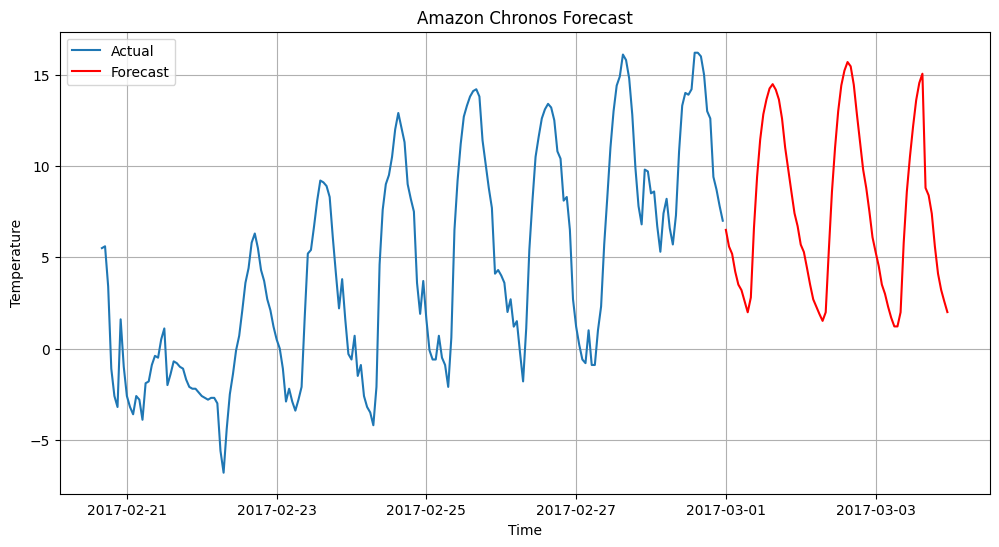

In [48]:
# Plot the df with the forecast
plt.figure(figsize = (12, 6))

# Actual values
plt.plot(df[-200:], label = "Actual")
# Forecast values
plt.plot(forecast_series, label = "Forecast", color = "red")

# Set title, legend, and labels
plt.title("Amazon Chronos Forecast")
plt.ylabel("Temperature")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()